#

<div align="center">
  
  <img src="https://i.ibb.co/21CrWWPP/Anahuac-Online.png" alt="Anahuac-Online" border="0">

  ### **UNIVERSIDAD ANÁHUAC**
  
  ---
  
  ## **DIPLOMADO EN INTELIGENCIA ARTIFICIAL**
  
  ### **Módulo 1: Python para la inteligencia artificial**
  #### **Unidad 5. Introducción a la econometría con Python**

  <br>
  <br>

  ## **RETO DE APRENDIZAJE:**
  # **Análisis de regresión lineal simple con Python**

  <br>
  <br>
  <br>

  ## **Presenta:**
  ### **José Salvador Aguilar Huerta**

  <br>
  <br>

  ## **Docente / Facilitador:**
  #### **Alejandro Platas López**

  <br>
  <br>
  <br>
  <br>
  <br>

---
  **Puebla, Pue. a 09 de Agosto de 2026**
</div>

<div style="page-break-after: always;"></div>

<h1 style="margin-top:10px; margin-bottom:8px;">
Análisis de regresión lineal simple con Python
</h1>

<hr style="margin-top:12px; margin-bottom:10px;">

<p style="font-size:16px; margin-top:4px; margin-bottom:4px;">
<strong>Objetivo</strong>
</p>
<p style="font-size:14px; text-align:justify; max-width:900px; margin:0 auto 14px auto;">
Aplicar los fundamentos de la estadística para generar, visualizar y analizar tres conjuntos de datos distintos mediante regresión lineal simple en Python, interpretando los resultados obtenidos y su grado de ajuste.
</p>
<p style="font-size:16px; margin-top:4px; margin-bottom:4px;">
<strong>Rubrica</strong>
</p>
<p style="font-size:14px; text-align:justify; max-width:900px; margin:0 auto 14px auto;">

| Criterio | Puntos | Que necesitas |
|----------|--------|---------------|
| Generacion y descripcion de datos | 4 | Tres conjuntos de datos, cada uno con 30-100 observaciones, bien descritos |
| Visualizacion y analisis grafico | 4 | Graficas de dispersion claras, con interpretacion de tendencias |
| Implementacion de regresion lineal | 5 | Codigo funcional con pendiente, intercepto y R² correctos |
| Analisis comparativo | 4 | Comparar los 3 modelos con argumentos estadisticos |
| Conclusiones y reflexion personal | 3 | Reflexion critica conectando teoria con tu practica profesional |

</p>


</div>

**Declaración de Librerías**

In [ ]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


 **CONJUNTO DE DATOS 1 — RELACION LINEAL FUERTE (NEGATIVA)**
 <br><br>
El Instituto de Energía Natural de Hawái sometio a mas de 1000 ciclos de carga un conjunto de 14 baterías NMC-LCO 18650, en cada ciclo tomó diferentes mediciones acerca de las condiciones de las baterias, entre ellas el indice de vida util restante. A partir de ese conjunto de datos se obtuvo una muestra aleatoria de 100 de esas mediciones, tomando unicamente el **número de ciclo** de la toma y el **indice de vida util restante**. Estos datos por su  naturaleza se espera tengan un comportamiento apegado a una función lineal ideal para este ejercicio, con lo que se esperaría un coeficiente de determinación $R^2$ cercano a $1$.
<br>
Los datos originales estan expuestos en: https://www.kaggle.com/datasets/ignaciovinuales/battery-remaining-useful-life-rul <br>
Y el extracto de datos a utilizar está alojado en: https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/Vida_Util_Baterias1.csv



**Carga inicial de datos**

In [ ]:
# ==============================
# Creación del Dataset 1 Relación Lineal
# ==============================

file_path = "https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/Vida_Util_Baterias1.csv"

# Cargar el archivo CSV
df1 = pd.read_csv(file_path)

# Mostrar confirmación de carga
print("Dataset cargado correctamente.")
print(f"Número de muestras y variables: {df1.shape}")

# Mostrar información general del dataset
#print("\nInformación general del dataset:")
#df1.info()

# Mostrar tipos de datos
print("\nTipos de datos por variable:")
print(df1.dtypes)

print(f"\nEstadisticas descriptivas:")
display(df1.describe())

print(f"\nGráfico de distribución:")
#Nos aseguramos que el dataset este en orden por el número de ciclo
df1.sort_values(by='Ciclos')

x1=df1['Ciclos'].values
y1=df1['Vida_Util'].values
#print(x1)
#print(y1)


Dataset cargado correctamente.
Número de muestras y variables: (100, 2)

Tipos de datos por variable:
Ciclos         int64
Vida_Util    float64
dtype: object

Estadisticas descriptivas:


,Ciclos,Vida_Util
count,100.000000,100.000000
mean,492.380000,54.670000
std,281.381217,25.059547
min,11.000000,10.000000
25%,259.500000,30.750000
50%,487.000000,56.500000
75%,766.000000,75.250000
max,995.000000,99.000000



Gráfico de distribución:


**Visualización Exploratoria**


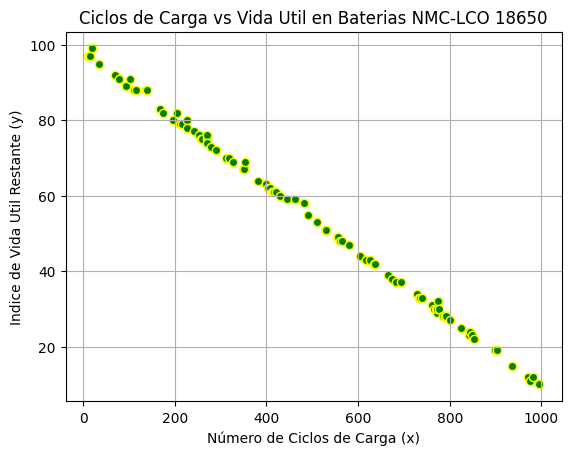

In [ ]:
# ==============================
# Graficación
# ==============================

x1=df1[['Ciclos']].values
y1=df1['Vida_Util'].values
plt.scatter(x1, y1, color='green', edgecolor='yellow')
plt.title('Ciclos de Carga vs Vida Util en Baterias NMC-LCO 18650')
plt.xlabel('Número de Ciclos de Carga (x)')
plt.ylabel('Indice de Vida Util Restante (y)')
plt.grid(True)
plt.show()


**OBSERVACIONES**<br>
Se confirma la relación lineal esperada con una tendencia negativa, lo que significa que a mayor número de ciclos de carga la vida util de las baterias tiende a ser menor.<br>
Tambien se observa una dispersion baja con lo que es de esperar un coeficiente de determinación $R^2$ cercano a $1$.

**DIVISIÓN (80/20)**

Entrenamiento: 80 observaciones
Prueba:        20 observaciones

Visualización


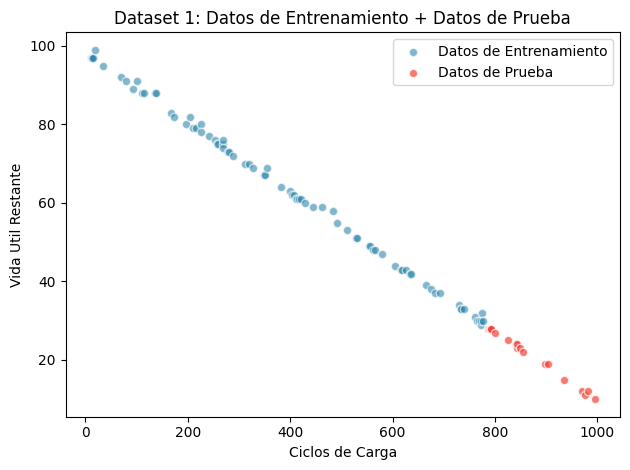

In [ ]:
############################################################################
## Creacion de subconjuntos de entrenamiento y prueba en una relación 80/20
############################################################################

#x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=20, random_state=42)

# Aplicaremos una division 80/20 ordenada soble el conjunto de datos sin usar un selector de aleatoriedad
# Esto nos permitirá entrenar nuestro modelo con datos historicos a una fecha y probar el modelo con datos futuros


x1_train = x1[:80]    # Primer 80% (del 0 al 79)
y1_train = y1[:80]    # Primer 80% (del 0 al 79)
x1_test = x1[80:]     # Ultimos 20% (del 80 al 99)
y1_test = y1[80:]     # Ultimos 20% (del 80 al 99)

print(f"Entrenamiento: {len(x1_train)} observaciones")
print(f"Prueba:        {len(x1_test)} observaciones")
print()
print(f"Visualización")

# Grafica: datos de entrenamiento + Datos de Prueba
plt.scatter(x1_train, y1_train, color='#2E86AB', alpha=0.6, label='Datos de Entrenamiento', edgecolors='white')
plt.scatter(x1_test, y1_test, color='#F24236', alpha=0.7, label='Datos de Prueba', edgecolors='white')
plt.xlabel('Ciclos de Carga')
plt.ylabel('Vida Util Restante')
plt.title(f'Dataset 1: Datos de Entrenamiento + Datos de Prueba')
plt.legend()
plt.tight_layout()
plt.show()



**Aplicación del Modelo Lineal Simple**<br>
Aplicaremos el método estadistico de regresión lineal simple y determinaremos las métricas que se utilizan para evaluar el modelo de regresión tales como el coeficiente de determinación ($R^2$), el error absoluto medio ($MAE$), el error cuadratico medio ($MSE$) y la raíz cuadrada del error cuadrático ($RMSE$) <br>
<br>
**Elementos del Modelo**<br>
***Variable Dependiente*** ($Y$): Es el valor que queremos pronosticar o explicar en nuestro ejemplo "La vida util restante de una batería".<br>
***Variable Independiente*** ($X$): Es el factor o predictor que usamos para hacer la estimación en nuestro caso "el número de ciclos de carga efectuados a la batería".<br>
***Línea Recta:*** Se representa con la ecuación ($Y = mX + B$).<br>
***Intercepto:*** El punto donde la recta cruza el eje vertical.<br>
***Pendiente ($m$):*** La inclinación de la recta, que indica cuánto cambia ($Y$) cuando ($X$) aumenta una unidad

In [ ]:
modelo1 = LinearRegression()
modelo1.fit(x1_train, y1_train)

y1_pred = modelo1.predict(x1_test)

pendiente1 = modelo1.coef_[0]
intercepto1 = modelo1.intercept_
r2_1 = r2_score(y1_test, y1_pred)
mae_1 = mean_absolute_error(y1_test, y1_pred)
mse_1 = mean_squared_error(y1_test, y1_pred)
rmse_1 = np.sqrt(mean_squared_error(y1_test, y1_pred))

print("=" * 80)
print("Resultados - Dataset 1: Ciclos de Carga vs Vida Util en Baterias NMC-LCO 18650")
print("=" * 80)
print(f"Ecuacion de la recta (y= mx + b): Vida Util = {pendiente1:.4f} * Ciclo + {intercepto1:.4f}")
print(f"Pendiente  :  {pendiente1:.4f}")
print(f"Intercepto :  {intercepto1:.4f}")
print(f"R²:            {r2_1:.4f}")
print(f"MAE:           {mae_1:.4f}")
print(f"MSE:           {mse_1:.4f}")
print(f"RMSE:          {rmse_1:.4f}")
print()


Resultados - Dataset 1: Ciclos de Carga vs Vida Util en Baterias NMC-LCO 18650
Ecuacion de la recta (y= mx + b): Vida Util = -0.0890 * Ciclo + 98.4992
Pendiente  :  -0.0890
Intercepto :  98.4992
R²:            0.9951
MAE:           0.3602
MSE:           0.1941
RMSE:          0.4406



**INTERPRETACION**<br>
El valor de la pendientes es $-0.0890$ lo que significa que por cada ciclo de carga las baterias reducen su vida util en un 0.089 unidades, dado que estamos midiendo la vida util como un porcentage en el rango de 0% a 100%, el resultado se traduce en una disminuciion del $0.089$%.

El modelo presenta un coeficiente de determinación $R^2=0.9951$ lo que se traduce como que el modelo explica 99.51% de la variabilidad en la vida util de las baterias.<br>

El error absoluto medio $MAE$ es de solo $0.3602$ lo que nos dice que en cada predicción que arroje el modelo tenemos una media de error con respecto al valor real de solo 0.3602, valores muy cercanos al dato real.<br>

Por otra parte el $RMSE$ nos indica otra medida de error entre las predicciónes y los datos reales, el propósito de ésta otra medición es ser mas sensible a datos extremos, si el modelo falla por mucho en un solo punto, el valor de RMSE sube notablemente a diferencía del $MAE$ que es mas estable ante datos extremos o valores atípicos. Siempre el $RMSE$ será mayor al $MAE$ y su diferencía nos  indica si hay errores grandes aislados. En nuestro caso la diferencia es ($0.4406 -0.3602 = 0.0804$) lo que denota muy baja o nula presencia de errores atípicos.




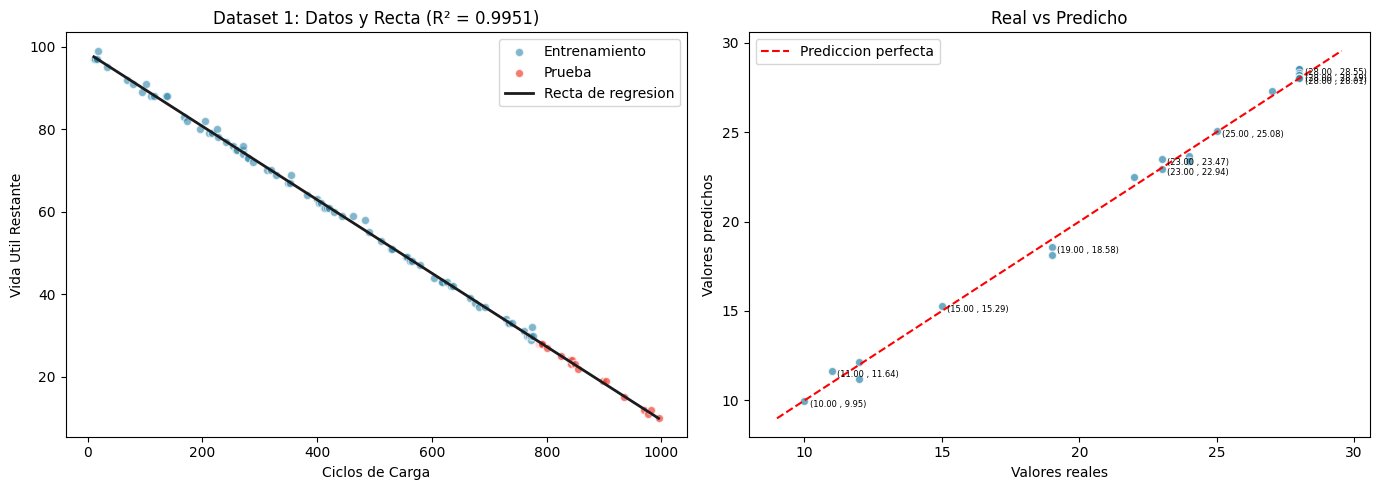

In [ ]:

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grafica izquierda: datos + recta de regresion
axes[0].scatter(x1_train, y1_train, color='#2E86AB', alpha=0.6, label='Entrenamiento', edgecolors='white')
axes[0].scatter(x1_test, y1_test, color='#F24236', alpha=0.7, label='Prueba', edgecolors='white')
x1_linea = np.linspace(x1.min(), x1.max(), 100).reshape(-1, 1)
axes[0].plot(x1_linea, modelo1.predict(x1_linea), color='#1B1B1E', linewidth=2, label='Recta de regresion')
axes[0].set_xlabel('Ciclos de Carga')
axes[0].set_ylabel('Vida Util Restante')
axes[0].set_title(f'Dataset 1: Datos y Recta (R² = {r2_1:.4f})')
axes[0].legend()

# Grafica derecha: valores reales vs predichos
axes[1].scatter(y1_test, y1_pred, color='#2E86AB', alpha=0.7, edgecolors='white')
lim = [min(y1_test.min()-1, y1_pred.min()), max(y1_test.max(), y1_pred.max()+1) ]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Valores predichos')
axes[1].set_title('Real vs Predicho')
axes[1].legend()
band=1
for i, j in zip(y1_test, y1_pred):
    axes[1].text(i+0.2, j - 0.2, f"({i:.2f} , {j:.2f})" if band<0 else "",fontsize=6, ha='left', va='center')
    band*=-1

plt.tight_layout()
plt.show()


**INTERPRETACION**
Las gráficas confirman lo interpretado con los resultados estadisticos, las predicciones que arroja el modelo son altamente apegadas a los los valores reales, la linea recta en la gráfica de la izquierda practicamente toca cada punto de la muestra lo que nos da ese sentido de certeza en el modelo. <br>
Por otra parte la gráfica de la derecha compara los valores predichos contra los reales, una predicción perfecta sería que la linea punteada tocara cada uno de esos punto, lo cual no sucede sin embargo los puntos estan muy cercanos a la linea lo que comprueba un $MAE$ de solo $0.362$ si observamos a detalle cada uno de los valores en cada punto podemos corroborar que la diferencia oscila alrededor de ésta media.<br>
Otro punto observable que que la vida util de éste modelo de baterias es de poco mas de 1000 recargas, si despejaramos X de la ecuacion de la recta podemos calcular su valor para Y=0 lo que resulta en ($98.4992/0.0890=1106.73$), esto es **1,107 ciclos de carga como vida util de las baterias**

_____
_____
 **CONJUNTO DE DATOS 2 — RELACION LINEAL MODERADA**
 <br><br>
El siguiente conjunto de datos corresponde a una extracción del conjunto de datos original "Advertising Dataset" publicado como parte del libro Introduction to Statistical Learning: with Applications de James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). Los datos expresan el gasto en miles de dolares en publicidad efectuado por una empresa contra el incremento de las ventas en miles de unidades, el dataset incluye 4 columnas etiquetadas como TV, Radio, Newspaper y Sales, las tres primeras son referente al gasto en publicidad y la ultima al incremento en unidades de venta. Para nuestro ejercicio solo estaremos ocupando El gasto en tv (TV) y el incremento en unidades de venta (Sales)
<br>
Los datos originales estan expuestos en: https://www.kaggle.com/datasets/tawfikelmetwally/advertising-dataset <br>
Y el extracto de datos a utilizar está alojado en: https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/TV_Radio_Newspaper_Sales,cvs



**Carga inicial de datos**

In [12]:
# ==================================================
# Creación del Dataset 2 Relación Lineal Moderada
# ===================================================

file_path = "https://raw.githubusercontent.com/aguilarhsalvador/Regresion-lineal-simple-con-Python/refs/heads/main/TV_Radio_Newspaper_Sales,cvs"

# Cargar el archivo CSV
df1 = pd.read_csv(file_path)

# Mostrar confirmación de carga
print("Dataset cargado correctamente.")
print(f"Número de muestras y variables: {df1.shape}")

# Mostrar información general del dataset
#print("\nInformación general del dataset:")
#df1.info()

# Mostrar tipos de datos
print("\nTipos de datos por variable:")
print(df1.dtypes)

print(f"\nEstadisticas descriptivas:")
display(df1.describe())

print(f"\nGráfico de distribución:")

x1=df1['TV'].values[:100]
y1=df1['Sales'].values[:100]
#print(x1)
#print(y1)


Dataset cargado correctamente.
Número de muestras y variables: (100, 4)

Tipos de datos por variable:
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Estadisticas descriptivas:


,TV,Radio,Newspaper,Sales
count,100.000000,100.00000,100.000000,100.000000
mean,148.647000,24.71100,32.350000,14.448000
std,83.776875,14.53639,21.530263,5.128401
min,5.400000,1.40000,0.300000,4.800000
25%,75.150000,12.37500,15.975000,10.600000
50%,145.100000,26.20000,31.550000,13.300000
75%,216.500000,36.87500,45.700000,18.075000
max,293.600000,49.60000,114.000000,25.400000



Gráfico de distribución:


**Visualización Exploratoria**


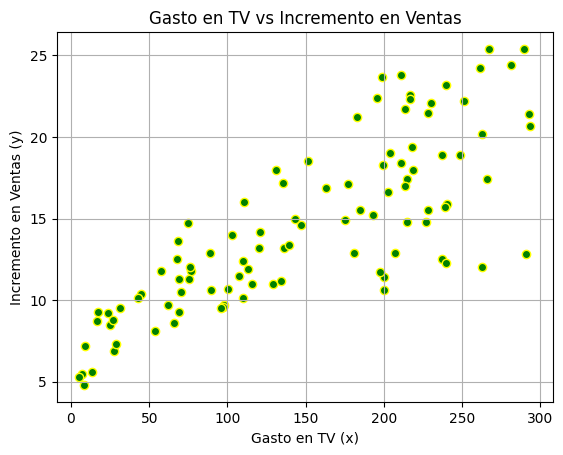

In [13]:
# ==============================
# Graficación
# ==============================

x1=df1[['TV']].values
y1=df1['Sales'].values
plt.scatter(x1, y1, color='green', edgecolor='yellow')
plt.title('Gasto en TV vs Incremento en Ventas')
plt.xlabel('Gasto en TV (x)')
plt.ylabel('Incremento en Ventas (y)')
plt.grid(True)
plt.show()


**OBSERVACIONES**<br>
Se observa una disperción moderada con una tendencia positiva, lo que se traduce que ante mayor gasto en publicidad televisiva exite un mayor incremento en las ventas. <br>
Dada la dispercion observada podemos esperar un coeficiente de determinación $R^2$ cercano al $0.5$.

**DIVISIÓN (80/20)**

Entrenamiento: 80 observaciones
Prueba:        20 observaciones

Visualización


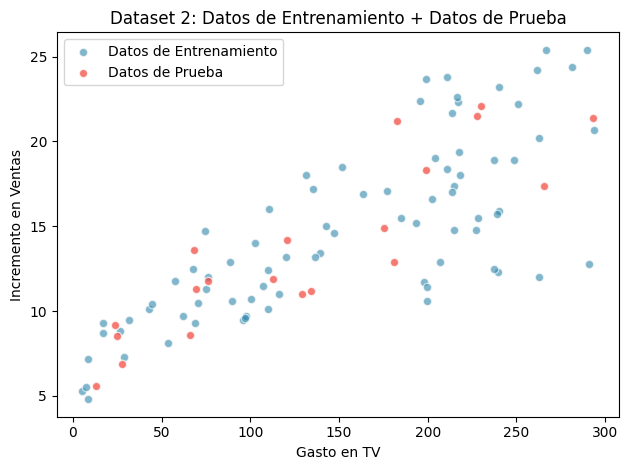

In [14]:
############################################################################
## Creacion de subconjuntos de entrenamiento y prueba en una relación 80/20
############################################################################

x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=20, random_state=42)

print(f"Entrenamiento: {len(x1_train)} observaciones")
print(f"Prueba:        {len(x1_test)} observaciones")
print()
print(f"Visualización")

# Grafica: datos de entrenamiento + Datos de Prueba
plt.scatter(x1_train, y1_train, color='#2E86AB', alpha=0.6, label='Datos de Entrenamiento', edgecolors='white')
plt.scatter(x1_test, y1_test, color='#F24236', alpha=0.7, label='Datos de Prueba', edgecolors='white')
plt.xlabel('Gasto en TV')
plt.ylabel('Incremento en Ventas')
plt.title(f'Dataset 2: Datos de Entrenamiento + Datos de Prueba')
plt.legend()
plt.tight_layout()
plt.show()



**Aplicación del Modelo Lineal Simple**<br>
Aplicaremos el método estadistico de regresión lineal simple y determinaremos las métricas que se utilizan para evaluar el modelo de regresión tales como el coeficiente de determinación ($R^2$), el error absoluto medio ($MAE$), el error cuadratico medio ($MSE$) y la raíz cuadrada del error cuadrático ($RMSE$) <br>
<br>
**Elementos del Modelo**<br>
***Variable Dependiente*** ($Y$): Es el valor que queremos pronosticar o explicar en nuestro ejemplo "Incremento en Ventas".<br>
***Variable Independiente*** ($X$): Es el factor o predictor que usamos para hacer la estimación en nuestro caso "Gasto en publicidad de TV".<br>
***Línea Recta:*** Se representa con la ecuación ($Y = mX + B$).<br>
***Intercepto:*** El punto donde la recta cruza el eje vertical.<br>
***Pendiente ($m$):*** La inclinación de la recta, que indica cuánto cambia ($Y$) cuando ($X$) aumenta una unidad

In [15]:
modelo1 = LinearRegression()
modelo1.fit(x1_train, y1_train)

y1_pred = modelo1.predict(x1_test)

pendiente1 = modelo1.coef_[0]
intercepto1 = modelo1.intercept_
r2_1 = r2_score(y1_test, y1_pred)
mae_1 = mean_absolute_error(y1_test, y1_pred)
mse_1 = mean_squared_error(y1_test, y1_pred)
rmse_1 = np.sqrt(mean_squared_error(y1_test, y1_pred))

print("=" * 80)
print("Resultados - Dataset 1: Gasto en Publicidad de TV vs Incremento en Ventas")
print("=" * 80)
print(f"Ecuacion de la recta (y= mx + b): Vida Util = {pendiente1:.4f} * Ciclo + {intercepto1:.4f}")
print(f"Pendiente  :  {pendiente1:.4f}")
print(f"Intercepto :  {intercepto1:.4f}")
print(f"R²:            {r2_1:.4f}")
print(f"MAE:           {mae_1:.4f}")
print(f"MSE:           {mse_1:.4f}")
print(f"RMSE:          {rmse_1:.4f}")
print()


Resultados - Dataset 1: Gasto en Publicidad de TV vs Incremento en Ventas
Ecuacion de la recta (y= mx + b): Vida Util = 0.0481 * Ciclo + 7.2836
Pendiente  :  0.0481
Intercepto :  7.2836
R²:            0.7827
MAE:           1.9182
MSE:           5.3830
RMSE:          2.3201



**INTERPRETACION**<br>
El valor de la pendientes es $0.0481$ lo que nos indica que por cada unidad de incremento del gasto en publicidad televisa (miles de dolares) se espera un incremento de 0.0481 en miles de unidades vendidas

El modelo presenta un coeficiente de determinación $R^2=0.7827$ lo que se traduce como que el modelo solo da respuesta al 78% de la variabilidad en en el icremento de las ventas,<br>

El error absoluto medio $MAE$ es de $1.9182$ lo que nos dice que en cada predicción que arroje el modelo tenemos una media de error con respecto al valor real de 1.918 unidades.<br>

Por otra parte el $RMSE$ nos indica otra medida de error entre las predicciónes y los datos reales, el propósito de ésta otra medición es ser mas sensible a datos extremos, si el modelo falla por mucho en un solo punto, el valor de RMSE sube notablemente a diferencía del $MAE$ que es mas estable ante datos extremos o valores atípicos. Siempre el $RMSE$ será mayor al $MAE$ y su diferencía nos  indica si hay errores grandes aislados. En nuestro caso la diferencia es ($2.3201 - 1.9182 = 0.4019) lo que denota una moderada presencia de errores atípicos.




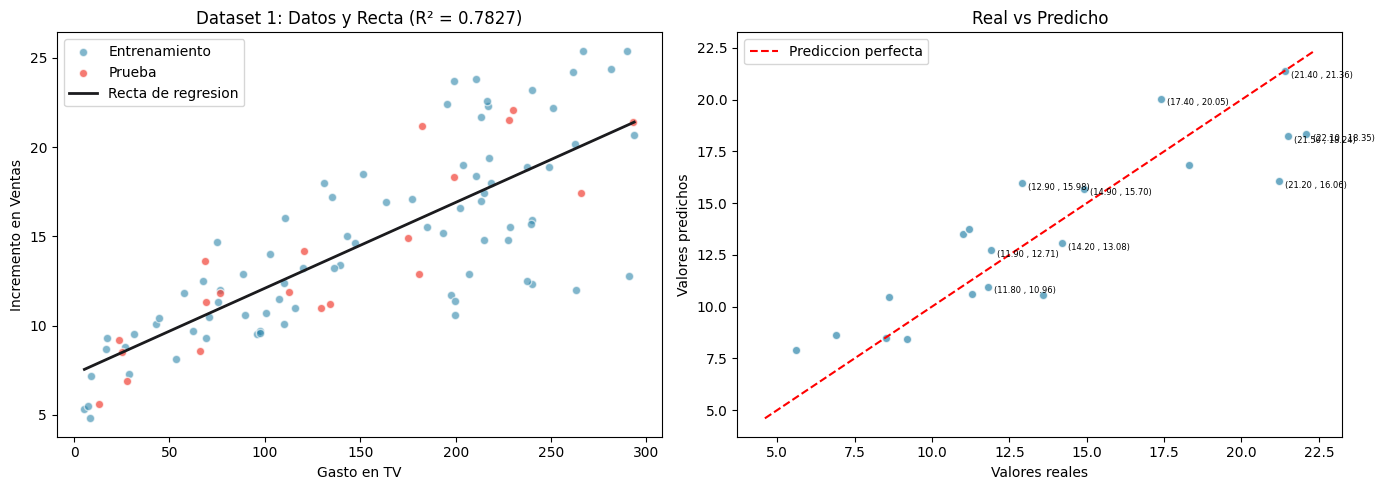

In [20]:

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Grafica izquierda: datos + recta de regresion
axes[0].scatter(x1_train, y1_train, color='#2E86AB', alpha=0.6, label='Entrenamiento', edgecolors='white')
axes[0].scatter(x1_test, y1_test, color='#F24236', alpha=0.7, label='Prueba', edgecolors='white')
x1_linea = np.linspace(x1.min(), x1.max(), 100).reshape(-1, 1)
axes[0].plot(x1_linea, modelo1.predict(x1_linea), color='#1B1B1E', linewidth=2, label='Recta de regresion')
axes[0].set_xlabel('Gasto en TV')
axes[0].set_ylabel('Incremento en Ventas')
axes[0].set_title(f'Dataset 1: Datos y Recta (R² = {r2_1:.4f})')
axes[0].legend()

# Grafica derecha: valores reales vs predichos
axes[1].scatter(y1_test, y1_pred, color='#2E86AB', alpha=0.7, edgecolors='white')
lim = [min(y1_test.min()-1, y1_pred.min()), max(y1_test.max(), y1_pred.max()+1) ]
axes[1].plot(lim, lim, 'r--', linewidth=1.5, label='Prediccion perfecta')
axes[1].set_xlabel('Valores reales')
axes[1].set_ylabel('Valores predichos')
axes[1].set_title('Real vs Predicho')
axes[1].legend()
band=1
for i, j in zip(y1_test, y1_pred):
    axes[1].text(i+0.2, j - 0.2, f"({i:.2f} , {j:.2f})" if band<0 else "",fontsize=6, ha='left', va='center')
    band*=-1

plt.tight_layout()
plt.show()


**INTERPRETACION**
Las gráficas confirman lo interpretado con los resultados estadisticos, las predicciones que arroja el modelo tiene una media de error alrededor de 1.91, la linea recta en la gráfica de la izquierda practicamente parte en dos el conjunto de datos pero tocando muy pocos puntos. <br>
Por otra parte la gráfica de la derecha compara los valores predichos contra los reales, una predicción perfecta sería que la linea punteada tocara cada uno de esos punto, lo culo que comprueba un $MAE$ de $1.91$ si observamos a detalle cada uno de los valores en cada punto podemos corroborar que la diferencia oscila alrededor de ésta media.<br>


-----
-----
 **Conjunto de datos 3 — Relacion lineal baja**
 <br><br>
***Dataset 2***: Nuevamente Se utilizará la funcion **sklearn.datasets.make_regression** pero incrementando el nivel de ruido (noise=40) para generar 100 datos con un comportamiento mas disperso pero no tal alejado de lo que sería una función lineal con lo que se esperaría un coeficiente de determinación $R^2$ entre $0.6$ y $0.8$.

***Dataset 3***: Para este caso utilizaremos ***numpy.random** con lo que generaremos un conjunto de 100 datos totalmente aleatorios por lo que se espera un conjunto sin relación lineal y con una alta dispersion, nuestro $R^2$ estaría muy cercano a $0$.


In [ ]:
# ==============================
# GENERACIÓN DE DATASETS
# ==============================
#
# Dataset 1: Relación Lineal
xx1, yy1 = make_regression(n_samples=100, n_features=1, noise=5.0, random_state=42)
print(xx1)
print(yy1)

# Dataset 2: Relación Moderada
x2, y2 = make_regression( n_samples=100, n_features=1, noise=40.0, random_state=42)

# Dataset 3: Sin Relación Lineal / Alta Dispersión
np.random.seed(42)
x3 = np.random.uniform(-3, 3,(100, 1))
y3 = np.random.uniform(-50, 50,100)

datasets = [
    ("Dataset 1: Alta Correlación", x1, y1),
    ("Dataset 2: Moderada Correlación", x2, y2),
    ("Dataset 3: Sin Relación / Ruido", x3, y3),
]
for idx, (name, x, y) in enumerate(datasets):
    # División 80/20
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


[[ 0.93128012]
 [ 0.08704707]
 [-1.05771093]
 [ 0.31424733]
 [-0.47917424]
 [ 0.64768854]
 [-0.46341769]
 [ 0.54256004]
 [ 0.61167629]
 [ 1.0035329 ]
 [ 0.8219025 ]
 [ 1.53803657]
 [ 0.73846658]
 [-0.21967189]
 [-0.8084936 ]
 [ 0.09176078]
 [-1.95967012]
 [ 0.51326743]
 [ 1.03099952]
 [-2.6197451 ]
 [ 0.49671415]
 [ 0.09707755]
 [-0.46572975]
 [ 0.91540212]
 [ 1.56464366]
 [ 1.46564877]
 [-0.60063869]
 [-0.03582604]
 [-0.60170661]
 [-1.19620662]
 [ 0.35711257]
 [ 0.37569802]
 [ 0.26105527]
 [-0.5297602 ]
 [-0.90802408]
 [ 0.19686124]
 [-0.29900735]
 [ 0.36163603]
 [ 0.82254491]
 [-0.29169375]
 [ 0.36139561]
 [-0.676922  ]
 [ 1.52302986]
 [-0.51827022]
 [-0.23415337]
 [-0.39210815]
 [-0.3011037 ]
 [-0.64511975]
 [ 0.32875111]
 [ 0.2088636 ]
 [-0.32766215]
 [ 0.00511346]
 [-0.23413696]
 [ 1.47789404]
 [-0.38508228]
 [ 0.34361829]
 [ 0.33126343]
 [-0.18565898]
 [-0.23458713]
 [-1.98756891]
 [ 0.32408397]
 [-0.2257763 ]
 [-1.10633497]
 [-0.70205309]
 [-1.46351495]
 [ 0.96864499]
 [-1.72491

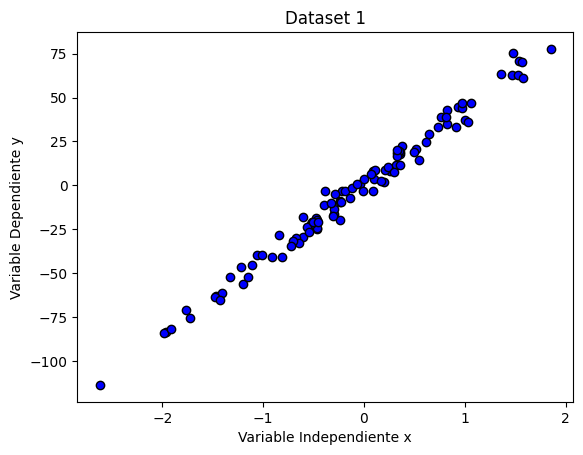

In [ ]:
#=========================================
# GRAFICACION DE DATASETS
#=========================================
plt.scatter(x1, y1, color='blue', edgecolor='k')
plt.title('Dataset 1')
plt.xlabel('Variable Independiente x')
plt.ylabel('Variable Dependiente y')
plt.grid(False)
plt.show()

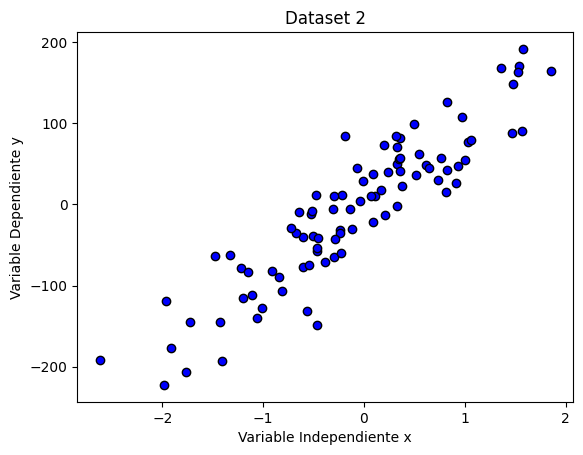

In [ ]:
# ==========================================
# GENERACIÓN DE DATASETS Y DIVISIÓN (80/20)
# ==========================================
plt.scatter(x2, y2, color='blue', edgecolor='k')
plt.title('Dataset 2')
plt.xlabel('Variable Independiente x')
plt.ylabel('Variable Dependiente y')
plt.grid(False)
plt.show()



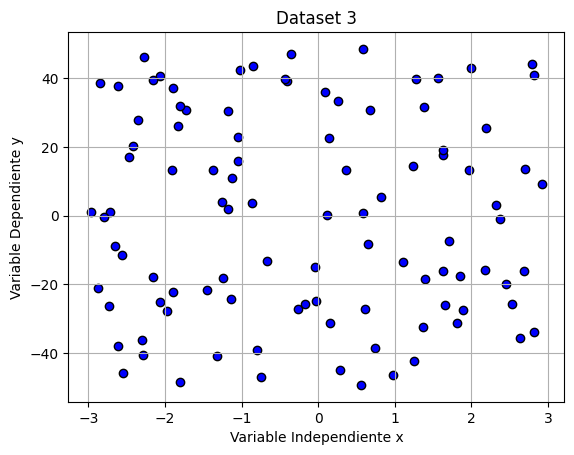

In [ ]:
# ==========================================
# GENERACIÓN DE DATASETS Y DIVISIÓN (80/20)
# ==========================================


plt.scatter(x3, y3, color='blue', edgecolor='k')
plt.title('Dataset 3')
plt.xlabel('Variable Independiente x')
plt.ylabel('Variable Dependiente y')
plt.grid(True)
plt.show()



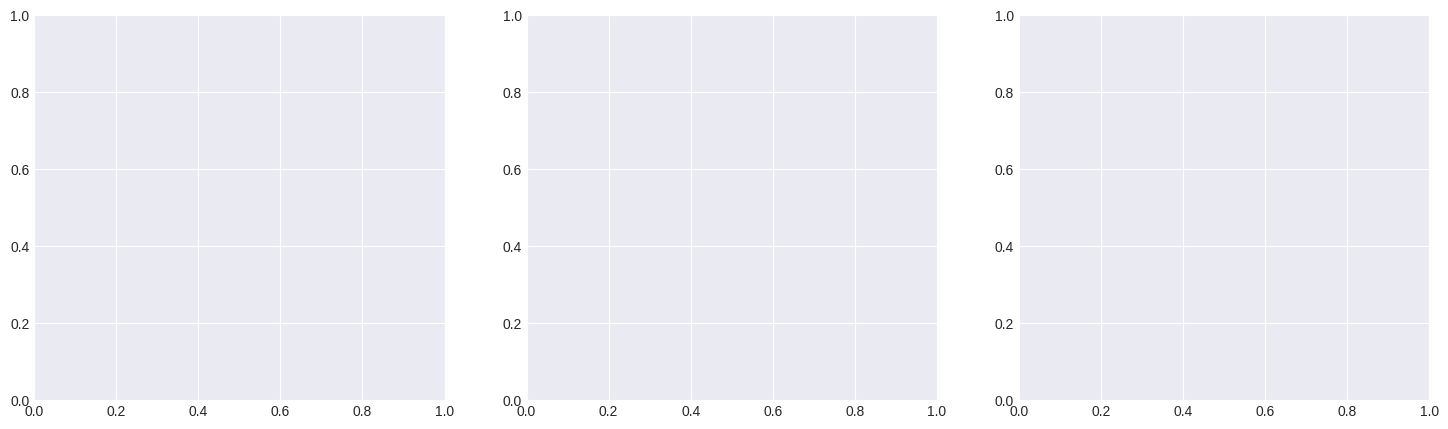

In [ ]:
# ==========================================
# GENERACIÓN DE DATASETS Y DIVISIÓN (80/20)
# ==========================================

datasets = [
    ("Dataset 1: Alta Correlación", x1, y1),
    ("Dataset 2: Moderada Correlación", x2, y2),
    ("Dataset 3: Sin Relación / Ruido", x3, y3),
]

results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [ ]:
# ==========================================
# 3. ENTRENAMIENTO, EVALUACIÓN Y VISUALIZACIÓN
# ==========================================
for idx, (name, X, y) in enumerate(datasets):
    # División 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Ajuste del modelo
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicciones
    y_pred = model.predict(X_test)

    # Cálculo de métricas sobre conjunto de prueba
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    slope = model.coef_[0]
    intercept = model.intercept_

    # Guardar métricas
    results.append(
        {
            "Dataset": name,
            "Pendiente (m)": round(slope, 3),
            "Intersección (b)": round(intercept, 3),
            "R²": round(r2, 4),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
        }
    )

    # Visualización
    ax = axes[idx]
    ax.scatter(
        X_train, y_train, color="blue", alpha=0.5, label="Entrenamiento (80%)"
    )
    ax.scatter(X_test, y_test, color="green", alpha=0.8, label="Prueba (20%)")

    # Línea de regresión
    X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(X_line)
    ax.plot(
        X_line,
        y_line,
        color="red",
        linewidth=2,
        label=f"Ajuste: y={slope:.1f}x+{intercept:.1f}",
    )

    ax.set_title(f"{name}\n($R^2$ = {r2:.3f})")
    ax.set_xlabel("Variable Independiente (X)")
    ax.set_ylabel("Variable Dependiente (Y)")
    ax.legend()

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

🔬 ANALIZANDO DATASET: Dataset A: Relación Lineal Positiva Fuerte

--- 📈 Resultados Cuantitativos ---
  R² (Coeficiente de Determinación): 0.9993
  MAE (Error Absoluto Medio):       0.84
  RMSE (Raíz Error Cuadrático):     1.02

--- 📝 Interpretación del Modelo ---
  Coeficiente (Pendiente/m): 41.991
  Intercepto (b):             0.010
🔬 ANALIZANDO DATASET: Dataset B: Relación Lineal Negativa Moderada

--- 📈 Resultados Cuantitativos ---
  R² (Coeficiente de Determinación): 0.9827
  MAE (Error Absoluto Medio):       4.21
  RMSE (Raíz Error Cuadrático):     5.10

--- 📝 Interpretación del Modelo ---
  Coeficiente (Pendiente/m): 42.993
  Intercepto (b):             0.050
🔬 ANALIZANDO DATASET: Dataset C: Relación Débil/Nula (Alto Ruido)

--- 📈 Resultados Cuantitativos ---
  R² (Coeficiente de Determinación): -0.1456
  MAE (Error Absoluto Medio):       40.89
  RMSE (Raíz Error Cuadrático):     52.61

--- 📝 Interpretación del Modelo ---
  Coeficiente (Pendiente/m): 30.516
  Intercepto (b):     

ValueError: Per-column arrays must each be 1-dimensional

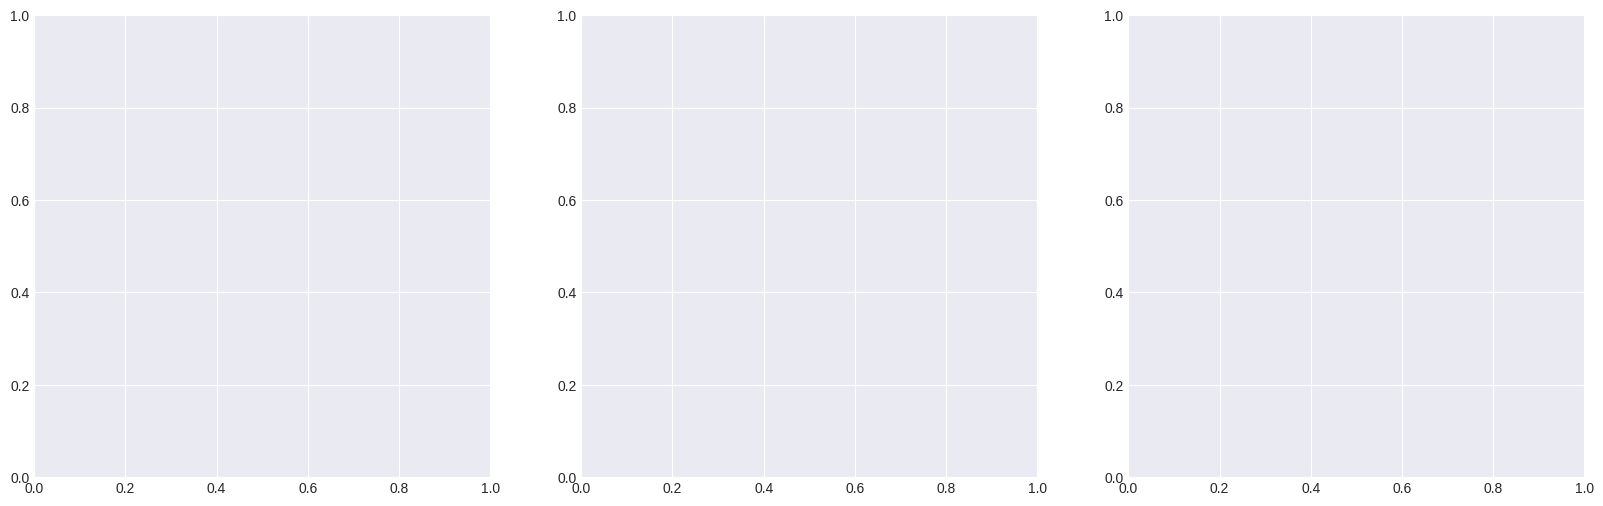

In [ ]:

# ---------------------------------------------------------
# Configuración inicial y estilos de visualización
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42) # Semilla global para reproducibilidad del proceso

def procesar_dataset(name, X_raw, y_raw):
    """Ejecuta el flujo completo de análisis: Split -> Regresión -> Evaluación."""
    print("="*60)
    print(f"🔬 ANALIZANDO DATASET: {name}")

    # 1. División Train-Test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42
    )

    # 2. Regresión Lineal Simple
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 3. Cálculo de Métricas
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    print("\n--- 📈 Resultados Cuantitativos ---")
    print(f"  R² (Coeficiente de Determinación): {r2:.4f}")
    print(f"  MAE (Error Absoluto Medio):       {mae:,.2f}")
    print(f"  RMSE (Raíz Error Cuadrático):     {rmse:,.2f}")

    # 4. Análisis de Parámetros
    print("\n--- 📝 Interpretación del Modelo ---")
    print(f"  Coeficiente (Pendiente/m): {model.coef_[0]:.3f}")
    print(f"  Intercepto (b):             {model.intercept_:.3f}")

    return {"R²": r2, "MAE": mae, "RMSE": rmse, "coef": model.coef_[0], "intercep": model.intercept_,
            "X_train": X_train, "X_test": X_test, "y_train": y_train, "y_test": y_test, "y_pred": y_pred}


# ============================================================================ #
# I. GENERACIÓN DE DATASETS Y EJECUCIÓN DEL FLUJO ANALÍTICO
# ============================================================================ #

# --- Dataset A: Relación Lineal Positiva Fuerte (R² alto esperado) ---
X_a, y_a = make_regression(n_samples=100, n_features=1, noise=1, random_state=42)
resultados_A = procesar_dataset("Dataset A: Relación Lineal Positiva Fuerte", X_a, y_a)


# --- Dataset B: Relación Lineal Negativa Moderada con Ruido (R² moderado esperado) ---
X_b, y_b = make_regression(n_samples=100, n_features=1, noise=5)
resultados_B = procesar_dataset("Dataset B: Relación Lineal Negativa Moderada", X_b, y_b)


# --- Dataset C: Relación Débil/Nula (R² bajo esperado) ---
X_c, y_c = make_regression(n_samples=100, n_features=1, noise=50, random_state=43)
resultados_C = procesar_dataset("Dataset C: Relación Débil/Nula (Alto Ruido)", X_c, y_c)


# ============================================================================ #
# II. VISUALIZACIÓN Y COMPARACIÓN FINAL
# ============================================================================ #

def visualizar(resultados):
    """Función que genera las gráficas de dispersión y regresión."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    datasets = {
        "A (Fuerte Positiva)": resultados['X_train'], "B (Negativa Ruido)": resultados['X_train'], "C (Débil/Nula)": resultados['X_train']
    }
    titles = ["Dataset A: Correlación Fuerte", "Dataset B: Baja Pendiente y Ruido", "Dataset C: Poco Predictivo"]

    for i, ax in enumerate(axes):
        # 1. Gráfico de Dispersión (Entrenamiento)
        sns.scatterplot(x=resultados['X_train'], y=resultados['y_train'], ax=ax, alpha=0.6, label="Datos Entrenamiento")
        # 2. Línea de Regresión
        ax.plot([resultados['X_train'].min(), resultados['X_train'].max()],
                [resultados['X_train'].mean() + resultados['coef'] * (resultados['X_test'].max()-resultados['X_test'].min()) / 2, # Aproximación de la recta en el rango
                 (resultados['y_test'].max() - resultados['y_test'].min())*0.5], # Valor arbitrario para dibujar una línea visible
                'r-', linewidth=3, label="Recta de Regresión")
        ax.set_title(titles[i])
        ax.set_xlabel("Variable X (Feature)")
        ax.set_ylabel("Variable Y (Target)")
        ax.legend()

    plt.tight_layout()
    plt.show()


# Ejecutar visualización y guardar la figura conceptualmente
visualizar(resultados_A) # Usamos A como ejemplo representativo para el gráfico final
